In [1]:
import os
import pickle
import matplotlib.pyplot as plt
import sys
internal_PC_dir = os.getcwd()
internal_MPC_dir = os.path.abspath(os.path.join(internal_PC_dir, '..'))
root_dir = os.path.abspath(os.path.join(internal_MPC_dir, '..'))
internal_CP_dir = os.path.abspath(os.path.join(root_dir, '6_Common_Paramaters'))
internal_1WSM_dir = os.path.abspath(os.path.join(internal_MPC_dir, '1_Without_System_model'))
internal_2WSM_dir = os.path.abspath(os.path.join(internal_MPC_dir, '4_With_System_model_modified'))
sys.path.append(internal_CP_dir)
import Common_Params as CP

c:\Users\home\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
without_system_model_path = os.path.abspath(os.path.join(internal_1WSM_dir, 'store_results_data'))
with_system_model_path = os.path.abspath(os.path.join(internal_2WSM_dir, 'store_results_data'))

In [3]:
for i, file in enumerate(os.listdir(without_system_model_path)):
    if file == 'times.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_times_without_system_model = pickle.load(f)
    elif file == 'separations.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_seperations_without_system_model = pickle.load(f)
    elif file == 'velocities.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_velocities_without_system_model = pickle.load(f)
    elif file  == 'accelerations.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_accelerations_without_system_model = pickle.load(f)
    elif file == 'detected_times.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_detected_times_without_system_model = pickle.load(f)
    elif file == 'start_reaction_times.pkl':
        with open(os.path.join(without_system_model_path, file), 'rb') as f:
            store_start_reaction_times_without_sytem_model = pickle.load(f)
    else:
        print('ERROR')            

In [4]:
for i, file in enumerate(os.listdir(with_system_model_path)):
    if file == 'times.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_times_with_system_model = pickle.load(f)
    elif file == 'separations.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_seperations_with_system_model = pickle.load(f)
    elif file == 'velocities.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_velocities_with_system_model = pickle.load(f)
    elif file  == 'accelerations.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_accelerations_with_system_model = pickle.load(f)
    elif file == 'detected_times.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_detected_times_with_system_model = pickle.load(f)
    elif file == 'start_reaction_times.pkl':
        with open(os.path.join(with_system_model_path, file), 'rb') as f:
            store_start_reaction_times_with_sytem_model = pickle.load(f)
    else:
        print('ERROR')            

In [5]:
def plot(store_times, store_accelerations, store_velocities, store_seperations, store_detected_times, store_start_reaction_times, Dr, Vp, title):
    fig, axes = plt.subplots(1, 3, figsize = (90, 25 * 1))                              # figsize = (width, height)
    font = 50
    border_thickness = 8.0
    
    for i in range(3):
        for spine in axes[i].spines.values():
            spine.set_linewidth(border_thickness)  # Set border (spine) thickness
    
    sri_1 = store_times[0].index(store_start_reaction_times[0])
    sri_2 = store_times[1].index(store_start_reaction_times[1])

    axes[0].plot(store_times[0], store_seperations[0], label = f'without_sytem_model (NO_SM)', color = 'purple', linewidth = 4)
    axes[0].plot(store_times[1], store_seperations[1], label = f'with_sytem_model (SM)', color = 'blue', linewidth = 4)
    axes[0].axvline(x = store_detected_times[0], color = 'black', linestyle = '--', label = 'Obstacle detected (NO_SM)', linewidth = 4)
    axes[0].axvline(x = store_start_reaction_times[0], color = 'red', linestyle = '--', label = 'Vehicle responds (NO_SM)', linewidth = 4)
    axes[0].axvline(x = store_detected_times[1], color = 'magenta', linestyle = '--', label = 'Obstacle detected (SM)', linewidth = 4)
    axes[0].axvline(x = store_start_reaction_times[1], color = 'orange', linestyle = '--', label = 'Vehicle responds (SM)', linewidth = 4)
    axes[0].plot(store_times[0][sri_1:], [CP.Dd + CP.Td * V * 5 / 18 for V in store_velocities[0][sri_1:]], label = f'Desired final seperation for PDC', color = 'green', linewidth = 6)
    axes[0].plot(store_times[1][sri_2:], [CP.Dd + CP.Td * V * 5 / 18 for V in store_velocities[1][sri_2:]], label = f'Desired final seperation for MPC', color = 'yellow', linewidth = 6)
    axes[0].grid(True, linewidth = 4.0)
    axes[0].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[0].set_ylabel('Separation [m]', fontsize = font, fontweight = 'bold')
    axes[0].set_title(title, fontsize = font, fontweight = 'bold')
    axes[0].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[0].legend(fontsize = font)

    axes[1].plot(store_times[0], store_velocities[0], label = f'without_sytem_model (NO_SM)', color = 'purple', linewidth = 4)
    axes[1].plot(store_times[1], store_velocities[1], label = f'with_sytem_model (SM)', color = 'blue', linewidth = 4)
    axes[1].axvline(x = store_detected_times[0], color = 'black', linestyle = '--', label = 'Obstacle detected (NO_SM)', linewidth = 4)
    axes[1].axvline(x = store_start_reaction_times[0], color = 'red', linestyle = '--', label = 'Vehicle responds (NO_SM)', linewidth = 4)
    axes[1].axvline(x = store_detected_times[1], color = 'magenta', linestyle = '--', label = 'Obstacle detected (SM)', linewidth = 4)
    axes[1].axvline(x = store_start_reaction_times[1], color = 'orange', linestyle = '--', label = 'Vehicle responds (SM)', linewidth = 4)
    axes[1].plot(store_times[0][sri_1:], [Vp * 18 / 5 for _ in range(len(store_velocities[0]))][sri_1:], label = f'Desired final velocity for PDC', color = 'green', linewidth = 4)
    axes[1].plot(store_times[1][sri_2:], [Vp * 18 / 5 for _ in range(len(store_velocities[1]))][sri_2:], label = f'Desired final velocity for MPC', color = 'yellow', linewidth = 4)
    axes[1].grid(True, linewidth = 4.0)
    axes[1].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[1].set_ylabel('Velocity [km/hr]', fontsize = font, fontweight = 'bold')
    axes[1].set_title(title, fontsize = font, fontweight = 'bold')
    axes[1].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[1].legend(fontsize = font)

    axes[2].plot(store_times[0], store_accelerations[0], label = f'without_sytem_model (NO_SM)', color = 'purple', linewidth = 4)
    axes[2].plot(store_times[1], store_accelerations[1], label = f'with_sytem_model (SM)', color = 'blue', linewidth = 4)
    axes[2].axvline(x = store_detected_times[0], color = 'black', linestyle = '--', label = 'Obstacle detected (NO_SM)', linewidth = 4)
    axes[2].axvline(x = store_start_reaction_times[0], color = 'red', linestyle = '--', label = 'Vehicle responds (NO_SM)', linewidth = 4)
    axes[2].axvline(x = store_detected_times[1], color = 'magenta', linestyle = '--', label = 'Obstacle detected (SM)', linewidth = 4)
    axes[2].axvline(x = store_start_reaction_times[1], color = 'orange', linestyle = '--', label = 'Vehicle responds (SM)', linewidth = 4)
    axes[2].grid(True, linewidth = 4.0)
    axes[2].set_xlabel('Time [s]', fontsize = font, fontweight = 'bold')
    axes[2].set_ylabel('Acceleration [m/s^2]', fontsize = font, fontweight = 'bold')
    axes[2].set_title(title, fontsize = font, fontweight = 'bold')
    axes[2].tick_params(axis = 'both', which = 'major', labelsize = font, width = 2)
    axes[2].legend(fontsize = font)

    plt.show()

In [6]:
titles = ['Cut in scenario (Scenario 3)', ' Slower preceding vehicle scenario (Scenario 2)', 'Complete stopping scenario (Scenario 1)', 'Cut in scenario (Scenario 3)']

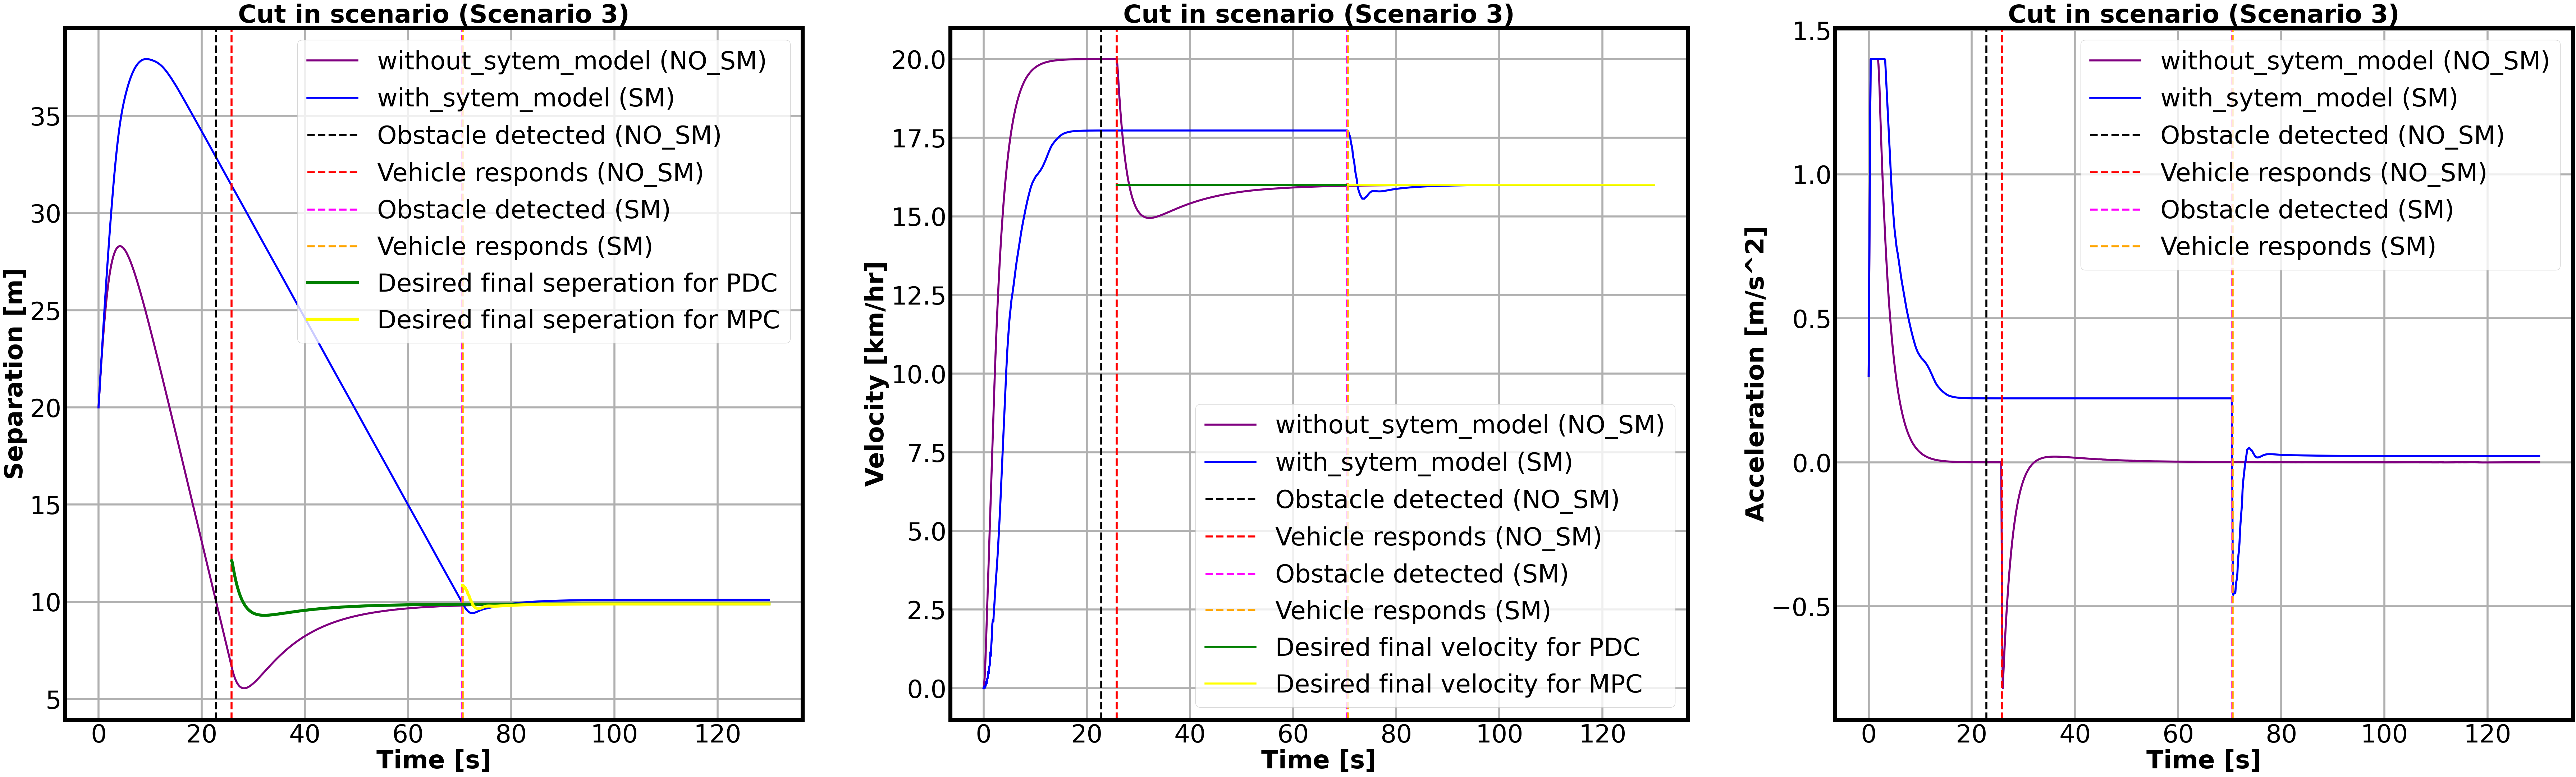

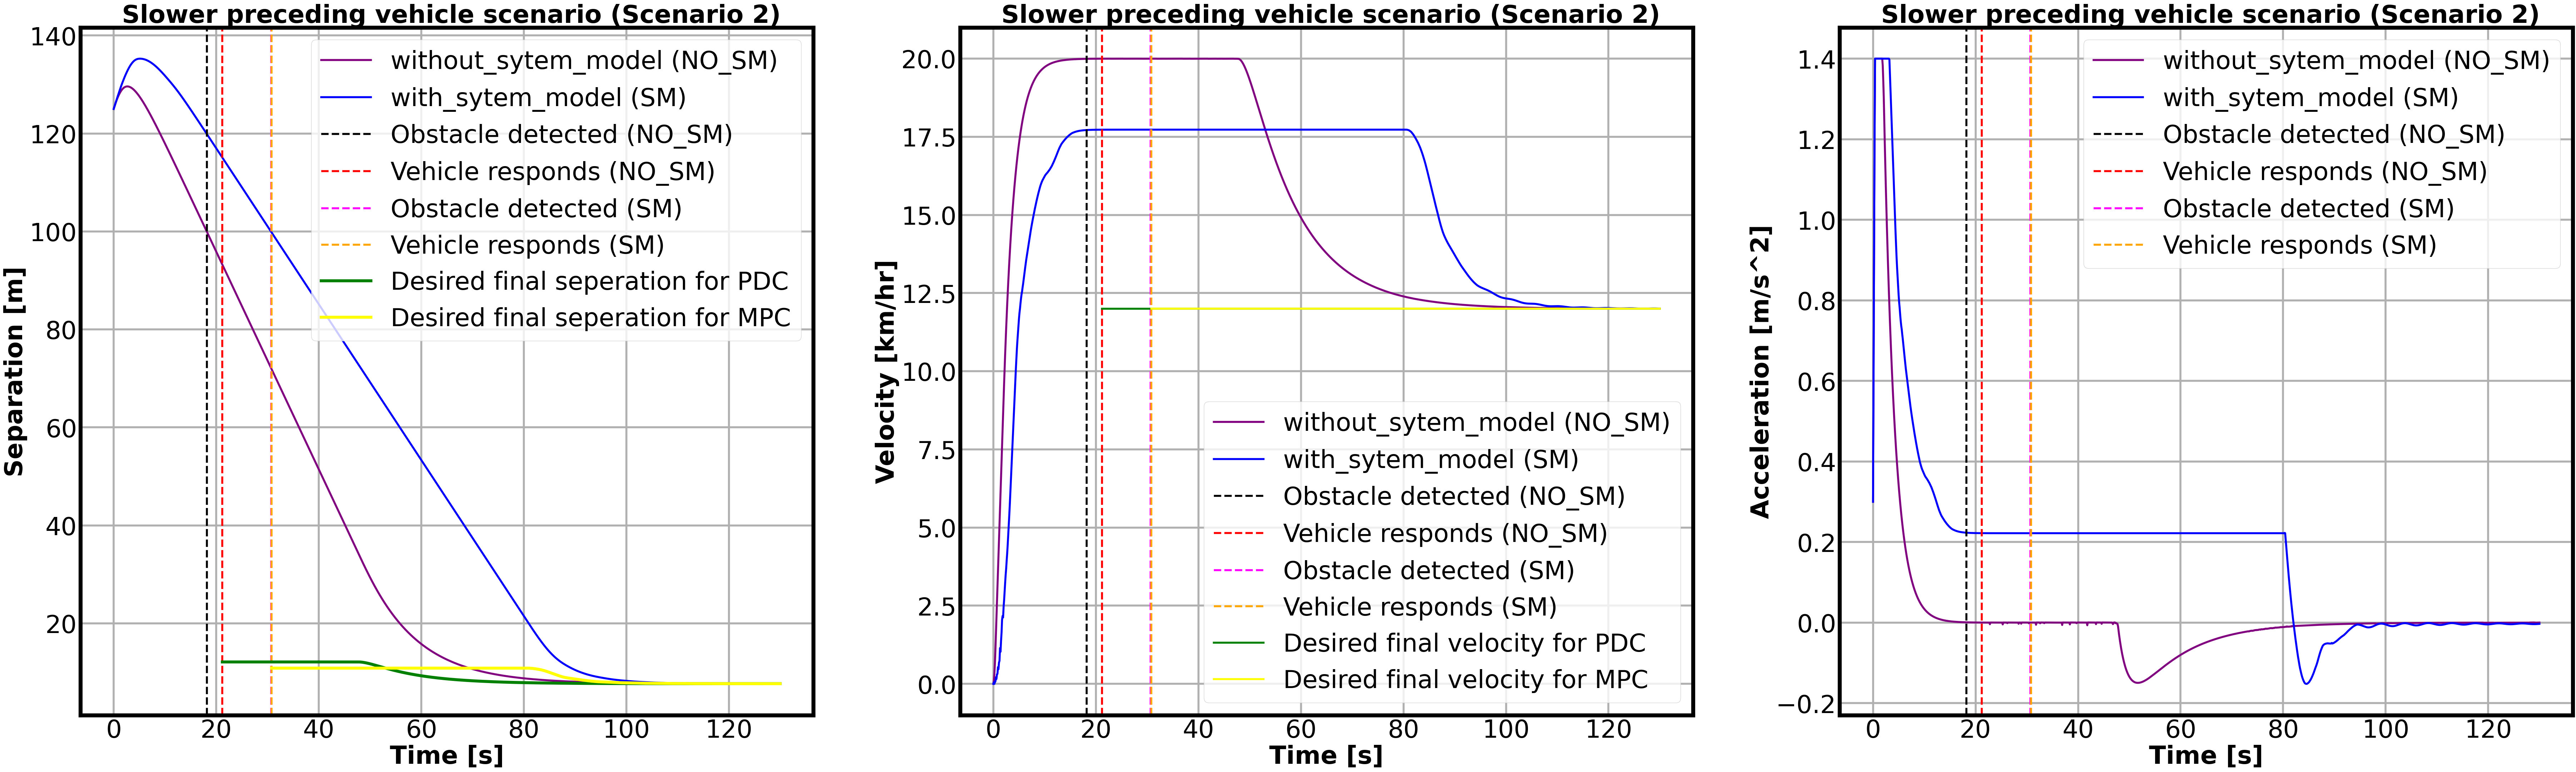

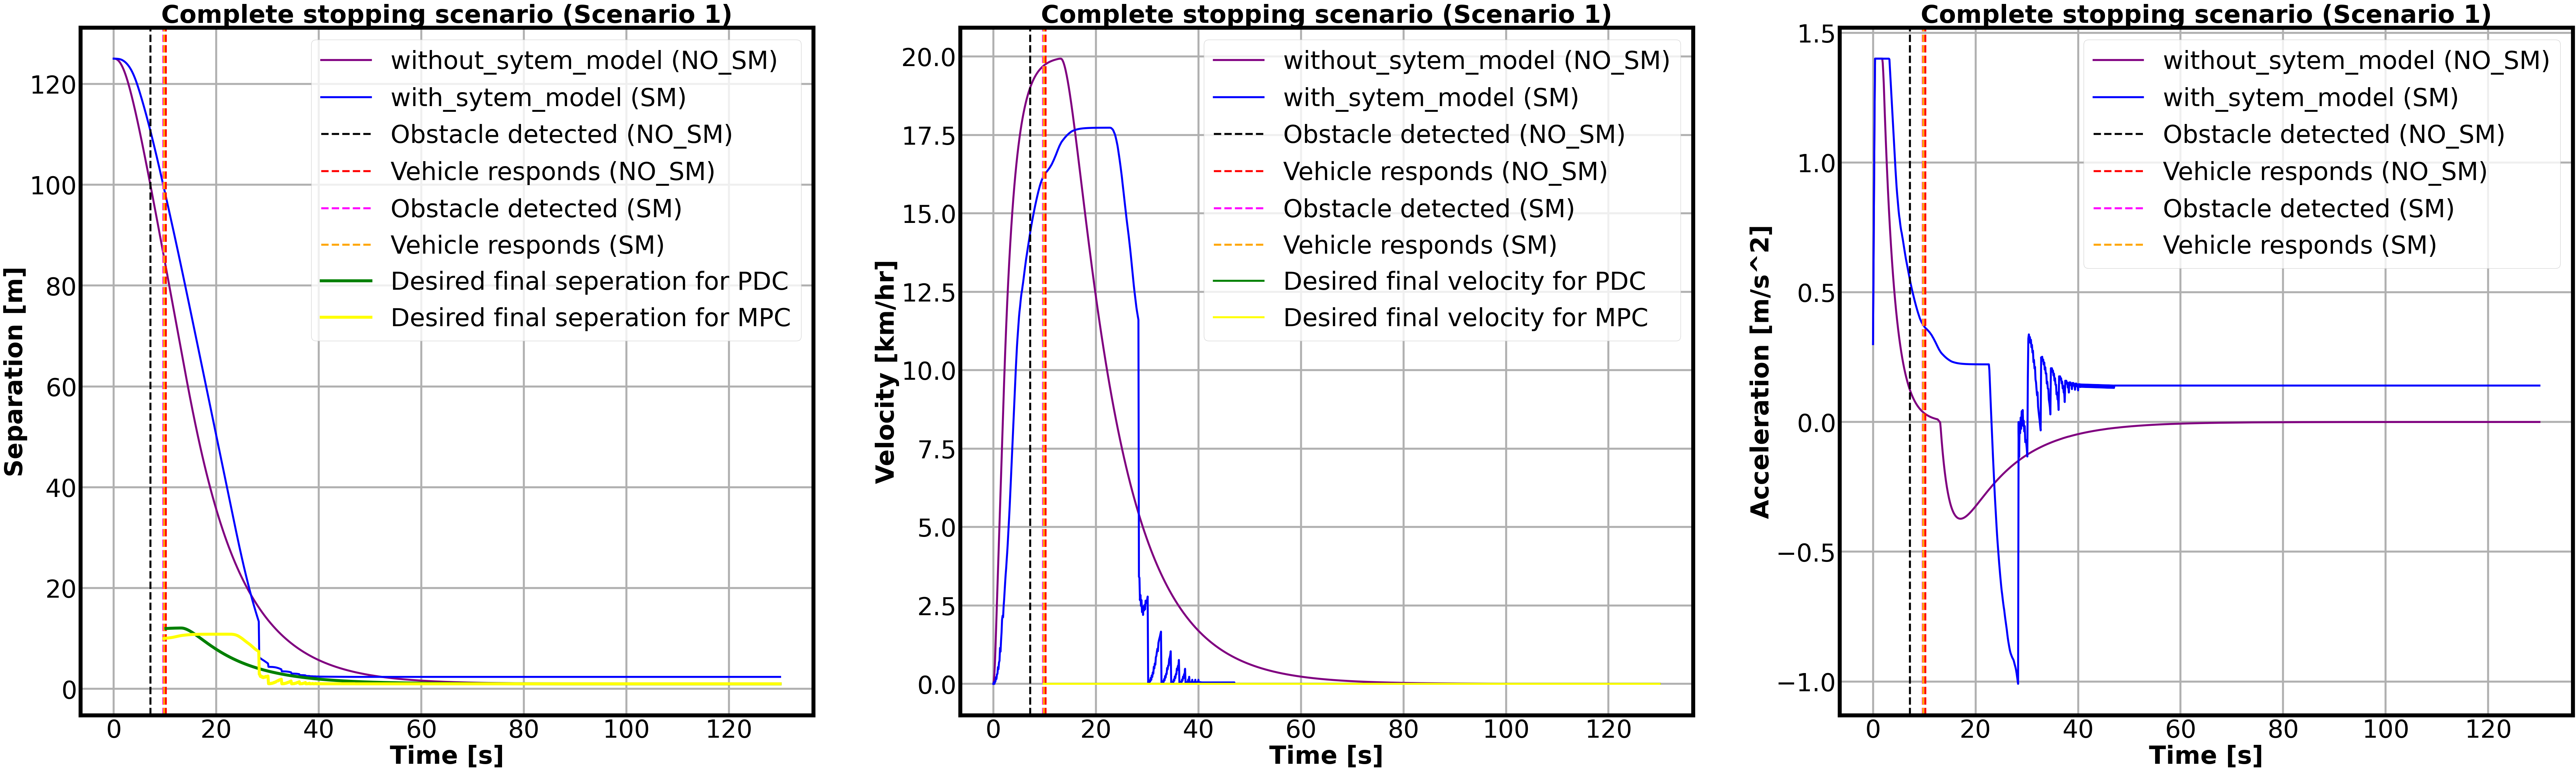

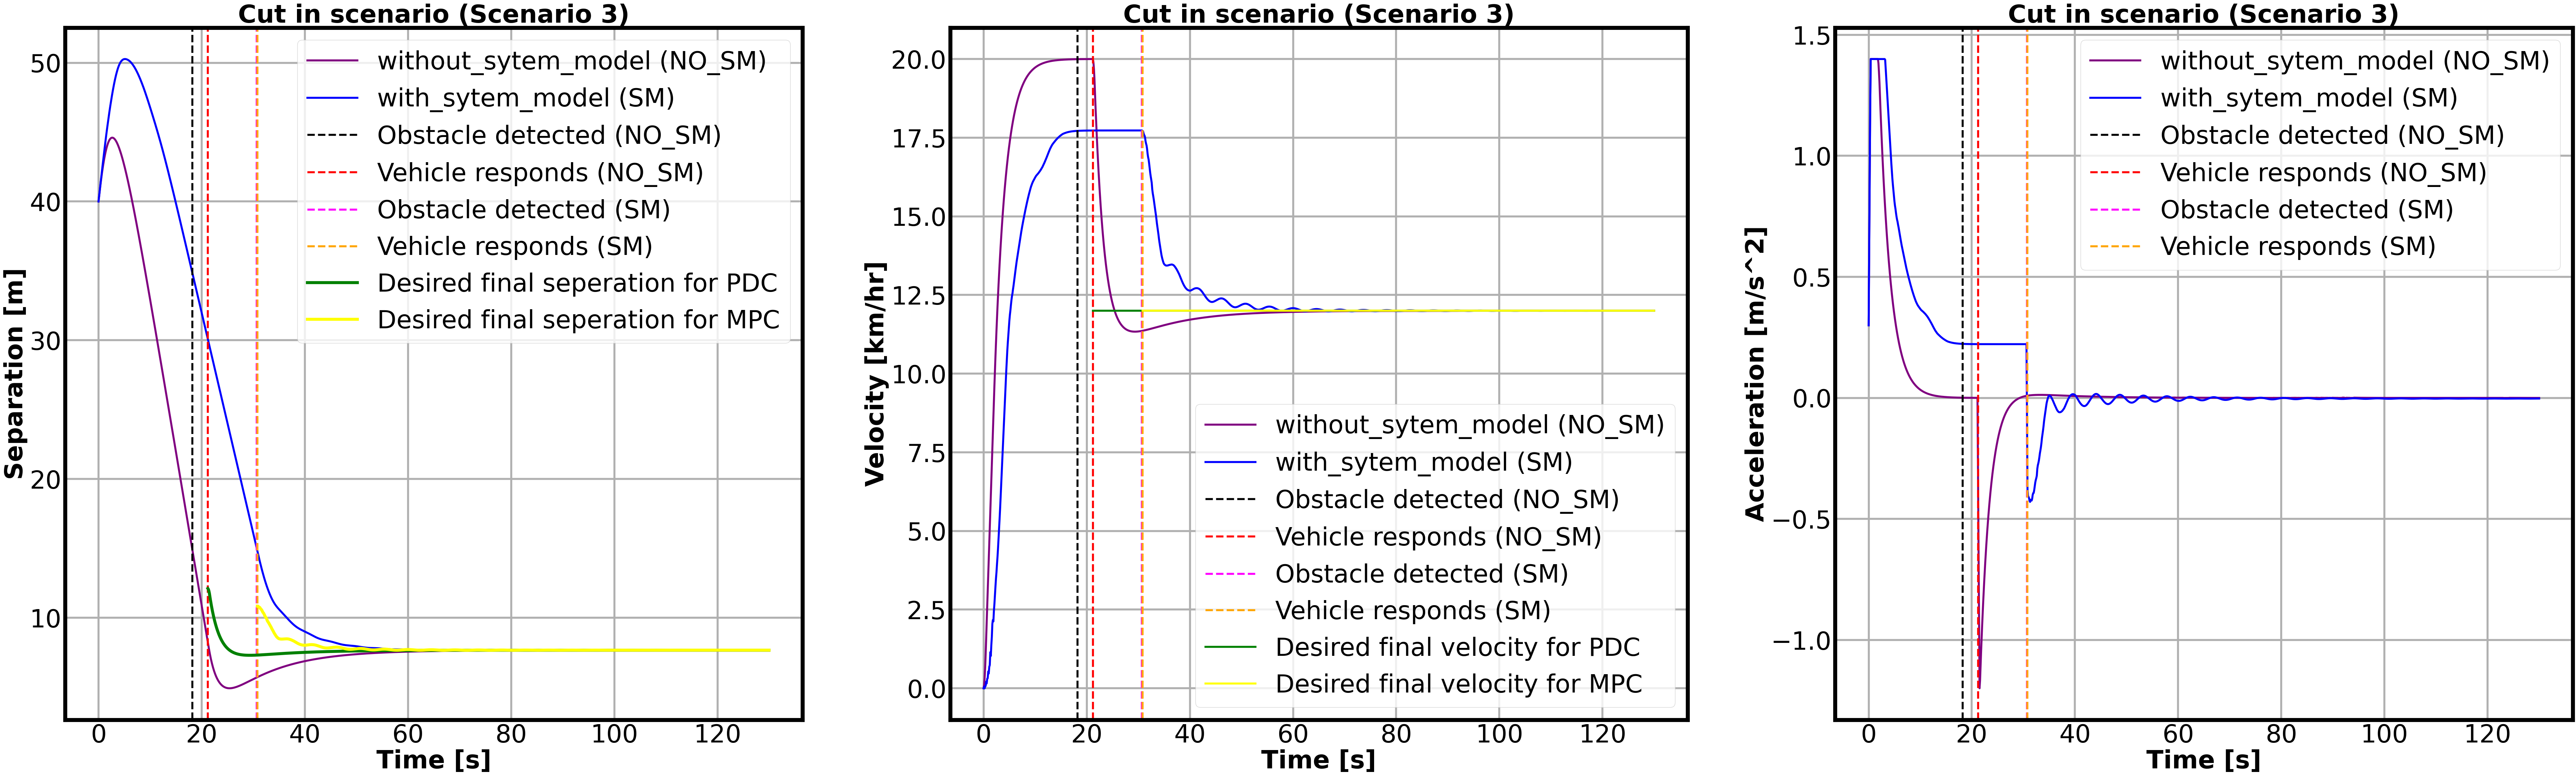

In [7]:
for i in range(len(store_times_without_system_model)):
    plot([store_times_without_system_model[i], store_times_with_system_model[i]], [store_accelerations_without_system_model[i], store_accelerations_with_system_model[i]], [store_velocities_without_system_model[i], store_velocities_with_system_model[i]], [store_seperations_without_system_model[i], store_seperations_with_system_model[i]], [store_detected_times_without_system_model[i], store_detected_times_with_system_model[i]], [store_start_reaction_times_without_sytem_model[i], store_start_reaction_times_with_sytem_model[i]], CP.Drs[i], CP.Vps[i], titles[i])